# Getting started

## What does `edge2torch` do?

`edge2torch` builds PyTorch models from edge lists of named neural architecture
nodes.

The core idea is to describe a model structure as a graph: each row in an
edgelist defines a directed connection from a `source` node to a `target` node.
`edge2torch` compiles this graph into a sparse PyTorch model that can be trained
with ordinary PyTorch tools.

Here, "graph" means the architecture specification, not necessarily a graph
neural network. Feedforward models, recurrent models, and graph neural networks
can all be represented by edge lists when their architecture is defined through
directed connections between named nodes.

This is useful whenever a neural architecture is known before training and can
be represented as named edges. Examples include sparse neural networks,
structured multilayer models, pathway-informed models, knowledge-primed neural
networks, and other graph-defined architectures.

## Domain example: knowledge-primed neural networks

One important use case is a knowledge-primed neural network (KPNN). In a KPNN,
prior knowledge encoded as a graph constrains the structure of a neural network.
Instead of starting from a fully generic architecture, the model structure is
informed by known relationships between named entities.

This is useful because the hidden nodes of the neural network can be designed to
correspond directly to meaningful domain entities. In a biological KPNN, for
example, hidden nodes may represent transcription factors, kinases, pathways, or
other biological processes. After training, attribution methods can then assign
importance scores not only to input features, but also to these hidden nodes.
Because the hidden nodes are mapped one-to-one to named biological entities,
node-level attributions can be interpreted as attributions for those entities.

The figure below illustrates this idea in a biological setting, where entities
such as genes, transcription factors, kinases, pathways, and phenotypes can be
connected through prior knowledge.

![KPNNs explained](../figures/KPNNs_explained.svg)

**Figure 1.** In a pathway-based KPNN, prior biological knowledge is encoded
directly into the neural network topology. Hidden nodes represent named
biological entities such as receptors, kinases, transcription factors, genes,
or pathways, and edges represent curated regulatory or signaling interactions.
This creates a sparse neural network in which information flow is constrained
by the provided biological graph, and attribution scores for neural network
nodes can be mapped back to the corresponding biological entities.

This is one domain-specific example of the broader `edge2torch` abstraction:
if a model architecture can be written as named edges, it can potentially be
compiled into a PyTorch model and interpreted back in the space of its named
features and nodes.

## The `edge2torch` workflow

The figure below summarizes the overall `edge2torch` workflow.

<img src="../figures/graphical_abstract.svg"
     alt="Graphical abstract of edge2torch"
     style="width: 100%; max-width: 100%;">

Starting point is a graph that describes the neural network architecture. In
`edge2torch`, this graph is represented as an edge list, where each row defines
a directed connection between named nodes. `compile_graph()` turns this edge
list into a minimally opinionated PyTorch model.

The compiled model can then be used like any other PyTorch `nn.Module`. You can
customize it with `customize_model()` or with ordinary PyTorch code by adding
activation functions, dropout, task-specific heads, or other downstream modules.
Training is also handled with standard PyTorch tools: losses, optimizers, and
training loops remain under user control.

After training, `interpret_model()` can compute feature-level or node-level
attributions. It uses the selected Captum attribution method and maps the
results back to the named features and nodes from the original edge list.

This notebook shows a basic `edge2torch` workflow:

1. represent a model architecture as an edgelist
2. compile the graph into a PyTorch model
3. use the compiled model like ordinary PyTorch
4. interpret the trained model back in the space of named features and nodes

The example uses biological names because KPNNs are a natural application area,
but the same workflow applies to other domains where the architecture can be
expressed as a graph.

## Installation

Install `edge2torch` from PyPI with:

```bash
pip install edge2torch
```

For optional `AnnData` support:

```bash
pip install "edge2torch[bio]"
```


## Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import display
from torch import nn

import edge2torch as e2t

In [2]:
sns.set_theme(style="whitegrid")

## Step 1: define a prior-knowledge graph

For v1, `edge2torch` expects an edgelist with two required columns:

- `source`
- `target`

Here we define a small feedforward biological graph with two clearly
separated branches:

- a **signal branch**, connected to informative input features
- a **noise branch**, connected to uninformative input features

This makes the later interpretation steps easier to understand: after
training, informative features and their connected hidden nodes should
receive stronger attributions than the uninformative branch.

A separate later section of this notebook shows how feedforward skip edges
are handled internally through pseudo nodes.


In [3]:
edgelist = pd.DataFrame(
    {
        "source": [
            "gene_signal_1",
            "gene_signal_2",
            "gene_signal_3",
            "gene_noise_1",
            "gene_noise_2",
            "gene_noise_3",
            "tf_signal",
            "tf_noise",
            "kinase_signal",
            "kinase_noise",
        ],
        "target": [
            "tf_signal",
            "tf_signal",
            "tf_signal",
            "tf_noise",
            "tf_noise",
            "tf_noise",
            "kinase_signal",
            "kinase_noise",
            "output_1",
            "output_1",
        ],
    }
)

edgelist

,source,target
0,gene_signal_1,tf_signal
1,gene_signal_2,tf_signal
2,gene_signal_3,tf_signal
3,gene_noise_1,tf_noise
4,gene_noise_2,tf_noise
5,gene_noise_3,tf_noise
6,tf_signal,kinase_signal
7,tf_noise,kinase_noise
8,kinase_signal,output_1
9,kinase_noise,output_1


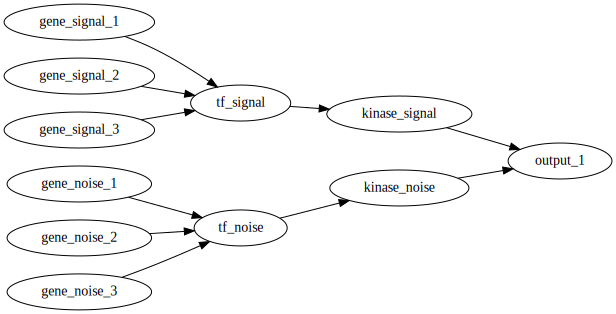

In [4]:
# Visualize the graph

dot = Digraph()
dot.attr(rankdir="LR")

input_nodes = [
    "gene_signal_1",
    "gene_signal_2",
    "gene_signal_3",
    "gene_noise_1",
    "gene_noise_2",
    "gene_noise_3",
]
layer_1_nodes = ["tf_signal", "tf_noise"]
layer_2_nodes = ["kinase_signal", "kinase_noise"]
output_nodes = ["output_1"]

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in input_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in layer_1_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in layer_2_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in output_nodes:
        s.node(node, node)

for _, row in edgelist.iterrows():
    dot.edge(row["source"], row["target"])

dot

## Step 2: compile the graph

`compile_graph(...)` returns:

- a compiled PyTorch model
- a compilation artifact containing the metadata needed later for
  interpretation


In [5]:
torch.manual_seed(1)

model, artifact = e2t.compile_graph(
    edgelist=edgelist,
    backend="feedforward",
)

type(model), type(artifact)

[edge2torch] Note: Graph contains 11 node(s) and 10 edge(s).
[edge2torch] Note: Feedforward backend selected. Graph must be layerable.


(edge2torch.nn.model.EdgeModel, edge2torch.compile.artifact.CompileArtifact)

## Inspect the artifact

The artifact is the compilation record returned alongside the PyTorch model. It
stores the backend, input feature order, layer-wise node names, graph
connectivity, and execution plan used to construct the model.

In [6]:
artifact.backend

'feedforward'

In [7]:
artifact.feature_names

['gene_noise_1',
 'gene_noise_2',
 'gene_noise_3',
 'gene_signal_1',
 'gene_signal_2',
 'gene_signal_3']

In [8]:
artifact.node_names_by_layer

{'layer_0': ['gene_noise_1',
  'gene_noise_2',
  'gene_noise_3',
  'gene_signal_1',
  'gene_signal_2',
  'gene_signal_3'],
 'layer_1': ['tf_noise', 'tf_signal'],
 'layer_2': ['kinase_noise', 'kinase_signal'],
 'layer_3': ['output_1']}

In [9]:
artifact.graph.edges

,source,target
0,gene_signal_1,tf_signal
1,gene_signal_2,tf_signal
2,gene_signal_3,tf_signal
3,gene_noise_1,tf_noise
4,gene_noise_2,tf_noise
5,gene_noise_3,tf_noise
6,tf_signal,kinase_signal
7,tf_noise,kinase_noise
8,kinase_signal,output_1
9,kinase_noise,output_1


## Step 3: simulate data and align it to the compiled model

The compiled model expects input features in the exact order stored in
`artifact.feature_names`. In practice, input data often comes from a DataFrame or
AnnData object where features are named but not necessarily ordered like the
model input layer.

`align_features_to_input_nodes()` uses the compilation artifact to reorder named
input features into the tensor layout expected by the model. This prevents
silent feature-order mismatches between the data and the compiled architecture.

For this tutorial, we first simulate a small binary classification dataset. The
`gene_signal_*` features carry class information, while the `gene_noise_*`
features are uninformative.

In [10]:
# Simulate the training and test data
rng = np.random.default_rng(1)

informative_features = [
    "gene_signal_1",
    "gene_signal_2",
    "gene_signal_3",
]

noise_features = [
    "gene_noise_1",
    "gene_noise_2",
    "gene_noise_3",
]

all_features = informative_features + noise_features

n_train_per_class = 100
n_test_per_class = 50


def simulate_binary_classification_data(n_per_class, rng):
    x0_signal = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x1_signal = rng.normal(
        loc=2.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )

    x0_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x1_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )

    x0 = np.concatenate([x0_signal, x0_noise], axis=1)
    x1 = np.concatenate([x1_signal, x1_noise], axis=1)

    x = np.concatenate([x0, x1], axis=0)
    y = np.concatenate(
        [
            np.zeros(n_per_class, dtype=int),
            np.ones(n_per_class, dtype=int),
        ]
    )

    permutation = rng.permutation(len(y))
    x = x[permutation]
    y = y[permutation]

    x_df = pd.DataFrame(x, columns=all_features)
    y_series = pd.Series(y, name="label")

    return x_df, y_series


x_train_df, y_train = simulate_binary_classification_data(
    n_per_class=n_train_per_class,
    rng=rng,
)

x_test_df, y_test = simulate_binary_classification_data(
    n_per_class=n_test_per_class,
    rng=rng,
)

display(x_train_df.head())
display(y_train.head())
display(x_test_df.head())
display(y_test.head())

,gene_signal_1,gene_signal_2,gene_signal_3,gene_noise_1,gene_noise_2,gene_noise_3
0,0.382930,-0.875721,-1.514319,0.287017,-0.578793,-0.876897
1,1.517455,1.217601,1.815758,0.163509,0.816011,-2.110056
2,0.245773,-0.746653,0.678740,0.878297,1.253826,-0.411778
3,1.760951,2.510922,3.001886,-0.288594,-1.136983,-0.619579
4,0.663658,1.972474,0.209167,0.759971,0.203371,1.658664


0    0
1    1
2    0
3    1
4    0
Name: label, dtype: int64

,gene_signal_1,gene_signal_2,gene_signal_3,gene_noise_1,gene_noise_2,gene_noise_3
0,0.096989,-0.170139,0.267756,0.777494,-1.892990,-0.051819
1,0.840300,1.595801,2.247646,-0.166935,-0.075523,-0.681671
2,-0.046298,0.553205,0.538196,1.204293,-0.605907,-0.042248
3,1.802631,1.617305,3.093590,-1.421344,0.028217,-1.256497
4,0.855323,-1.541040,-0.419259,2.527698,0.303440,1.674191


0    0
1    1
2    0
3    1
4    0
Name: label, dtype: int64

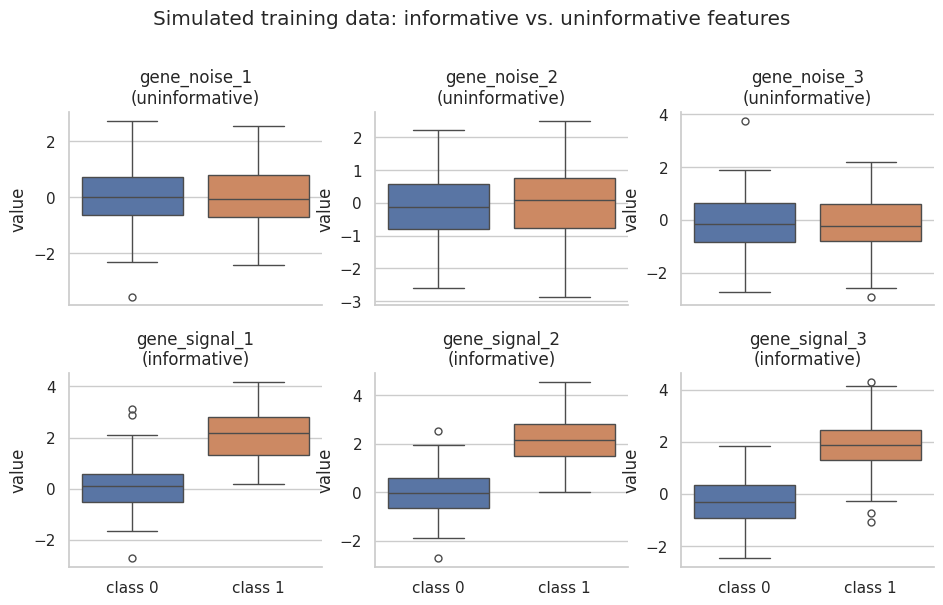

In [11]:
# Visualize the simulated training data

import matplotlib.pyplot as plt
import seaborn as sns

plot_df = x_train_df.copy()
plot_df["label"] = y_train.values
plot_df["class"] = plot_df["label"].map({0: "class 0", 1: "class 1"})

long_df = plot_df.melt(
    id_vars=["label", "class"],
    value_vars=artifact.feature_names,
    var_name="feature",
    value_name="value",
)

feature_type_map = {
    "gene_signal_1": "informative",
    "gene_signal_2": "informative",
    "gene_signal_3": "informative",
    "gene_noise_1": "uninformative",
    "gene_noise_2": "uninformative",
    "gene_noise_3": "uninformative",
}

long_df["feature_type"] = long_df["feature"].map(feature_type_map)

g = sns.catplot(
    data=long_df,
    x="class",
    y="value",
    col="feature",
    col_wrap=3,
    hue="class",
    kind="box",
    sharey=False,
    height=3.2,
    aspect=1.0,
    legend=False,
)

g.fig.suptitle(
    "Simulated training data: informative vs. uninformative features",
    y=0.98,
)

g.fig.subplots_adjust(top=0.82, hspace=0.35)

for ax, feature in zip(g.axes.flat, artifact.feature_names):
    feature_type = feature_type_map[feature]
    ax.set_title(f"{feature}\n({feature_type})")
    ax.set_xlabel("")
    ax.set_ylabel("value")

plt.show()

In [12]:
x_train = e2t.align_features_to_input_nodes(
    data=x_train_df,
    artifact=artifact,
)

x_test = e2t.align_features_to_input_nodes(
    data=x_test_df,
    artifact=artifact,
)

x_train.shape, x_test.shape

(torch.Size([200, 6]), torch.Size([100, 6]))

To verify that alignment is based on feature names, we deliberately reverse the
DataFrame columns and align the shuffled DataFrame again. The result is identical
to the original aligned tensor.

In [13]:
# Alignment is name-based, not position-based.
# Even if the DataFrame columns are shuffled, the aligned tensor is unchanged.

shuffled_columns = list(reversed(artifact.feature_names))
x_train_df_shuffled = x_train_df[shuffled_columns]

x_train_from_shuffled = e2t.align_features_to_input_nodes(
    data=x_train_df_shuffled,
    artifact=artifact,
)

torch.allclose(x_train, x_train_from_shuffled)

True

## Step 4: customize the compiled model

The compiled model is intentionally minimal. It defines the graph-derived
structural core, but it does not impose architectural choices such as
activation functions, dropout, or output heads.

For this binary classification example, we add a one-dimensional linear head
that outputs a single logit.

We do not add a downstream ReLU here. The compiled graph already ends in a
single output node, and applying ReLU to this scalar bottleneck can suppress
gradients into the graph if the output is negative. The linear head keeps the
example simple while making the model suitable for binary classification with
standard PyTorch loss functions.

In [14]:
customized_model = e2t.customize_model(
    model=model,
    head=nn.Linear(1, 1),
)

customized_model

CustomizedEdgeModel(
  (base_model): EdgeModel(
    (blocks): ModuleList(
      (0-2): 3 x FeedforwardLayerBlock(
        (linear): MaskedLinear()
      )
    )
  )
  (head): Linear(in_features=1, out_features=1, bias=True)
)

## Step 5: train the compiled and customized model in PyTorch

The customized model is still a normal PyTorch module. This means it can be
trained with ordinary PyTorch components such as loss functions, optimizers,
and training loops.

Below is a minimal training step that shows how the compiled structural core
and the added architectural components fit directly into a standard PyTorch
workflow.

Loss before first update: 0.6963
Loss after final update:  0.0577


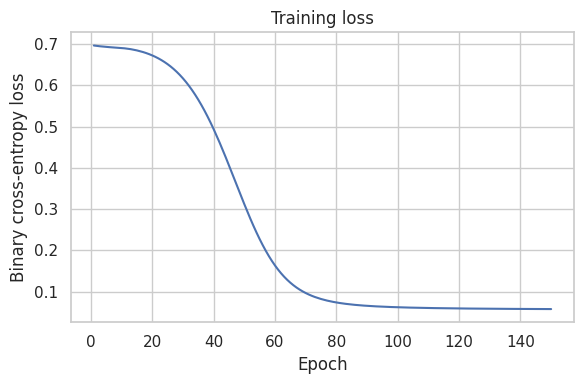

In [15]:
# Train the model with the simulated data

x_train = torch.tensor(
    x_train_df[artifact.feature_names].values,
    dtype=torch.float32,
)
y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    customized_model.parameters(),
    lr=1e-2,
)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 150
loss_history = []

customized_model.train()

for epoch in range(n_epochs):
    optimizer.zero_grad()

    logits = customized_model(x_train)
    loss = loss_fn(logits, y_train_tensor)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

print("Loss before first update:", round(loss_history[0], 4))
print("Loss after final update: ", round(loss_history[-1], 4))

plt.figure(figsize=(6, 4))
plt.plot(range(1, n_epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Step 6: feature-level interpretation

Feature-level interpretation maps attributions back to the input features.

For this example, we use:

- `target="features"`
- `method="integrated_gradients"`

Because the dataset was simulated, we know which features truly separate the
two classes: the `gene_signal_*` features were generated with different class
means, whereas the `gene_noise_*` features were not.

This gives us a useful sanity check for interpretation. The recovered feature
attributions do not need to match the simulated class mean differences exactly,
but the informative features should generally receive larger attribution
magnitudes than the uninformative ones.

In [16]:
feature_attr = e2t.interpret_model(
    model=customized_model,
    artifact=artifact,
    data=x_test_df,
    target="features",
    method="IntegratedGradients",
)

feature_attr.head()

[edge2torch] Finished interpretation with method 'IntegratedGradients' for target 'features'.


,gene_noise_1,gene_noise_2,gene_noise_3,gene_signal_1,gene_signal_2,gene_signal_3
0,-0.149702,-0.228903,0.018503,0.198181,-0.417863,0.663634
1,0.032142,-0.009132,0.243402,1.717015,3.919306,5.570787
2,-0.231880,-0.073267,0.015085,-0.094603,1.358677,1.333919
3,0.273672,0.003412,0.448653,3.683382,3.972121,7.667459
4,-0.486695,0.036692,-0.597798,1.747713,-3.784814,-1.039132


In [17]:
# Summarize feature attributions and compare them to the simulated signal

class_mean_diff = (
    x_test_df.loc[y_test == 1].mean() - x_test_df.loc[y_test == 0].mean()
)

feature_summary = pd.DataFrame(
    {
        "feature": artifact.feature_names,
        "abs_class_mean_difference": (
            class_mean_diff.abs().reindex(artifact.feature_names).values
        ),
        "mean_abs_attribution": (
            feature_attr.abs()
            .mean(axis=0)
            .reindex(artifact.feature_names)
            .values
        ),
        "mean_signed_attribution": (
            feature_attr.mean(axis=0).reindex(artifact.feature_names).values
        ),
    }
)

feature_type_map = {
    "gene_signal_1": "informative",
    "gene_signal_2": "informative",
    "gene_signal_3": "informative",
    "gene_noise_1": "uninformative",
    "gene_noise_2": "uninformative",
    "gene_noise_3": "uninformative",
}

feature_summary["feature_type"] = feature_summary["feature"].map(
    feature_type_map
)

feature_summary

,feature,abs_class_mean_difference,mean_abs_attribution,mean_signed_attribution,feature_type
0,gene_noise_1,0.094806,0.155169,-0.019322,uninformative
1,gene_noise_2,0.319823,0.102062,0.003031,uninformative
2,gene_noise_3,0.204747,0.283213,-0.019432,uninformative
3,gene_signal_1,2.111796,2.958739,1.838984,informative
4,gene_signal_2,2.164730,3.633556,2.449118,informative
5,gene_signal_3,2.159934,3.772523,2.598134,informative


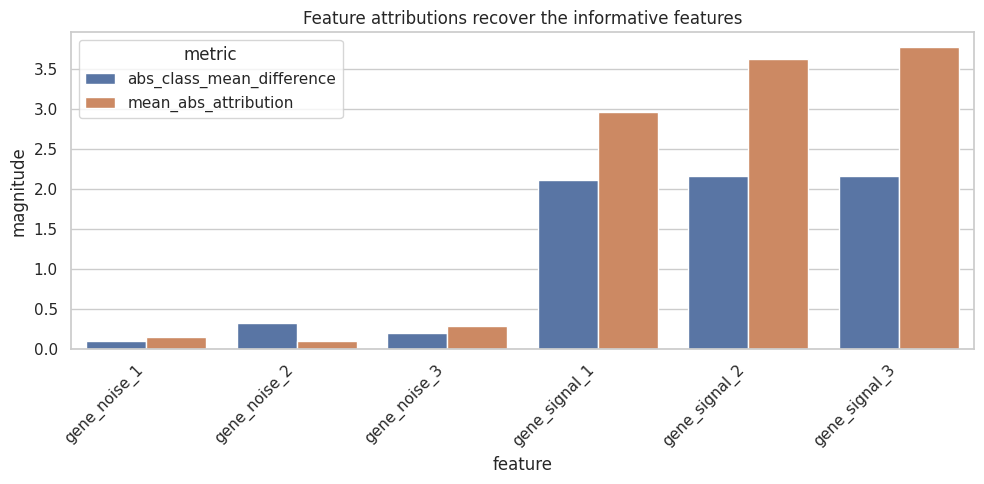

In [18]:
# Plot recovered attributions against the true simulated signal

plot_df = feature_summary.melt(
    id_vars=["feature", "feature_type"],
    value_vars=[
        "abs_class_mean_difference",
        "mean_abs_attribution",
    ],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="feature",
    y="value",
    hue="metric",
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("feature")
plt.ylabel("magnitude")
plt.title("Feature attributions recover the informative features")
plt.tight_layout()
plt.show()

## Step 7: node-level interpretation

Node-level interpretation maps attribution scores back to the internal nodes of
the compiled graph.

For this example, we use:

- `target="nodes"`
- `method="layer_conductance"`

This is often the most interesting interpretation level, because it helps show
which hidden biological entities in the network carry signal for the task.

The returned object is a dictionary:

- keys = layer names such as `"layer_1"` or `"layer_2"`
- values = pandas DataFrames
  - rows = test examples
  - columns = node names in that layer

Because this dataset was simulated with informative and uninformative feature
groups, we expect nodes on the informative branch of the graph to tend to show
larger attribution magnitudes than nodes on branches driven mainly by noise.

Internal pseudo nodes are automatically hidden from the returned results.

In [19]:
node_attr = e2t.interpret_model(
    model=customized_model,
    artifact=artifact,
    data=x_test_df,
    target="nodes",
    method="LayerConductance",
)

list(node_attr.keys())

[edge2torch] Finished interpretation with method 'LayerConductance' for target 'nodes'.


['layer_1', 'layer_2', 'layer_3']

The layer-wise node attribution tables can be inspected directly.

In [20]:
for layer_name, layer_df in node_attr.items():
    print(layer_name)
    display(layer_df.head())

layer_1


,tf_noise,tf_signal
0,-0.359709,0.443468
1,0.266122,11.194893
2,-0.289745,2.595162
3,0.724946,15.306261
4,-1.046658,-3.072880


layer_2


,kinase_noise,kinase_signal
0,-0.359709,0.443468
1,0.266122,11.194894
2,-0.289745,2.595161
3,0.724946,15.306257
4,-1.046658,-3.072880


layer_3


,output_1
0,0.083759
1,11.461016
2,2.305416
3,16.031204
4,-4.119538


To make the node-level results easier to interpret, we now summarize the
attributions across the test set.

For each node, we compute:

- the mean attribution
- the mean absolute attribution

The mean absolute attribution is often especially useful, because it reflects
overall importance even when positive and negative values cancel out on average.

In [21]:
node_summary_frames = []

for layer_name, layer_df in node_attr.items():
    layer_summary = pd.DataFrame(
        {
            "layer": layer_name,
            "node": layer_df.columns,
            "mean_attribution": layer_df.mean(axis=0).values,
            "mean_abs_attribution": layer_df.abs().mean(axis=0).values,
        }
    )
    node_summary_frames.append(layer_summary)

node_summary = (
    pd.concat(node_summary_frames, ignore_index=True)
    .sort_values(
        ["layer", "mean_abs_attribution"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

node_summary

,layer,node,mean_attribution,mean_abs_attribution
0,layer_1,tf_signal,6.878730,9.126178
1,layer_1,tf_noise,-0.035684,0.320601
2,layer_2,kinase_signal,6.878729,9.126178
3,layer_2,kinase_noise,-0.035684,0.320601
4,layer_3,output_1,6.843047,9.144727


The following plot shows the mean absolute attribution for each internal node
across the test set.

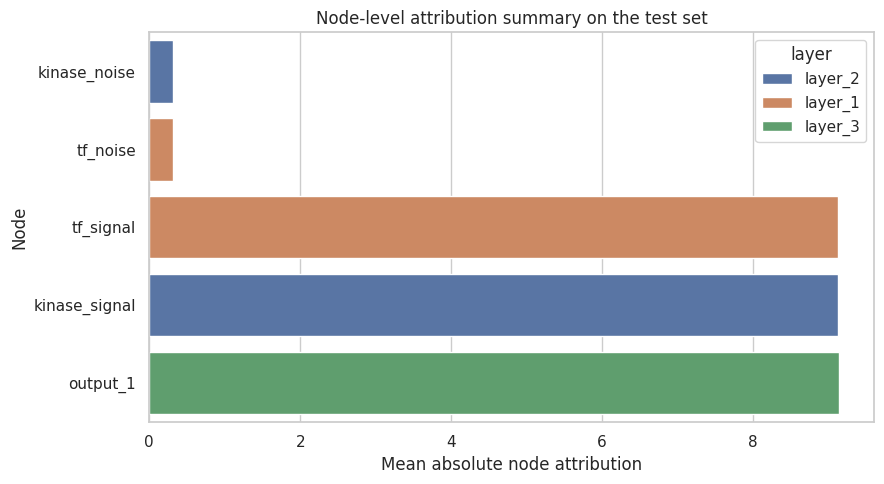

In [22]:
plot_df = node_summary.sort_values(
    "mean_abs_attribution",
    ascending=True,
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=plot_df,
    x="mean_abs_attribution",
    y="node",
    hue="layer",
    dodge=False,
)
plt.xlabel("Mean absolute node attribution")
plt.ylabel("Node")
plt.title("Node-level attribution summary on the test set")
plt.tight_layout()
plt.show()